In [1]:
from pathlib import Path
import json
import math
import random
import time
import sys

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

torch.backends.cudnn.benchmark = True

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "manifests").is_dir() and (path / "src").is_dir():
            return path
    raise RuntimeError("Could not find project root containing manifests/ and src/.")

PROJECT_ROOT = find_project_root()
TRAIN_MANIFEST = PROJECT_ROOT / "manifests" / "lasher_synthetic_train.jsonl"
TEST_MANIFEST = PROJECT_ROOT / "manifests" / "lasher_synthetic_test.jsonl"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) in sys.path:
    sys.path.remove(str(SRC_PATH))
sys.path.insert(0, str(SRC_PATH))

# Notebook kernels can cache an older installed/local madnet module. Force the source tree version.
for module_name in ["madnet.model", "madnet"]:
    if module_name in sys.modules:
        del sys.modules[module_name]

from madnet.model import build_model
print(f"madnet source={sys.modules['madnet.model'].__file__}")

def choose_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")
    try:
        torch.empty(1, device="cuda")
        return torch.device("cuda")
    except Exception as exc:
        print(f"CUDA is visible but not usable in this session; falling back to CPU: {exc}")
        return torch.device("cpu")


DEVICE = choose_device()
LABEL_SCALE = torch.tensor([100.0, 100.0], dtype=torch.float32)

CONFIG = {
    "model_name": "madnet_v1_5_coarse_to_fine",
    "task_version": "v1_5_coarse_to_fine",
    "pool_size": 8,
    "base_channels": 24,
    "dropout": 0.0,
    "x_bound": 100.0,
    "y_bound": 100.0,
    "image_size": 224,
    "batch_size": 128,
    "num_workers": 20,
    "pin_memory": True,
    "epochs": 20,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "train_limit": None,
    "test_limit": None,
    "seed": 42,
    "memory_debug_every": 100,  # set to 0 to disable CUDA memory logging
}
LABEL_SCALE = torch.tensor([CONFIG["x_bound"], CONFIG["y_bound"]], dtype=torch.float32)
print(f"project_root={PROJECT_ROOT}")
print(f"device={DEVICE}")

/home/user/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


madnet source=/home/user/MADNet/src/madnet/model.py
project_root=/home/user/MADNet
device=cuda


In [2]:
class LasherSyntheticDataset(Dataset):
    def __init__(self, manifest_path, image_size=224, limit=None, seed=42):
        self.manifest_path = Path(manifest_path)
        self.records = self._load_records(limit=limit, seed=seed)
        self.rgb_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])
        self.ir_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5,), std=(0.5,)),
        ])

    def _load_records(self, limit, seed):
        with self.manifest_path.open("r", encoding="utf-8") as fh:
            records = [json.loads(line) for line in fh if line.strip()]
        if limit is not None and limit < len(records):
            rng = random.Random(seed)
            indices = sorted(rng.sample(range(len(records)), limit))
            records = [records[i] for i in indices]
        return records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        visible = Image.open(record["visible"]["path"]).convert("RGB")
        infrared = Image.open(record["infrared"]["path"]).convert("L")

        rgb = self.rgb_transform(visible)
        ir = self.ir_transform(infrared)
        target_px = torch.tensor([
            record["infrared"]["dx"],
            record["infrared"]["dy"],
        ], dtype=torch.float32)
        target = target_px / LABEL_SCALE
        return rgb, ir, target


def make_loader(dataset, batch_size, shuffle, num_workers, pin_memory=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )


train_dataset = LasherSyntheticDataset(
    TRAIN_MANIFEST,
    image_size=CONFIG["image_size"],
    limit=CONFIG["train_limit"],
    seed=CONFIG["seed"],
)
test_dataset = LasherSyntheticDataset(
    TEST_MANIFEST,
    image_size=CONFIG["image_size"],
    limit=CONFIG["test_limit"],
    seed=CONFIG["seed"],
)

train_loader = make_loader(
    train_dataset,
    CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"] and DEVICE.type == "cuda",
)
test_loader = make_loader(
    test_dataset,
    CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"] and DEVICE.type == "cuda",
)

rgb, ir, target = next(iter(train_loader))
print(f"train_pairs={len(train_dataset):,} test_pairs={len(test_dataset):,}")
print(f"rgb={tuple(rgb.shape)} ir={tuple(ir.shape)} target={tuple(target.shape)}")
print(f"first target normalized={target[0].tolist()}")
print(f"first target pixels={(target[0] * LABEL_SCALE).tolist()}")

train_pairs=373,008 test_pairs=173,584
rgb=(128, 3, 224, 224) ir=(128, 1, 224, 224) target=(128, 2)
first target normalized=[-0.47999998927116394, 0.05999999865889549]
first target pixels=[-48.0, 6.0]


In [3]:
model = build_model(
    CONFIG["model_name"],
    corr_radius=CONFIG.get("corr_radius", 8),
    corr_head_channels=CONFIG.get("corr_head_channels", 128),
    feature_channels=CONFIG.get("feature_channels", 64),
    encoder_stride=CONFIG.get("encoder_stride", 8),
    softmax_temperature=CONFIG.get("softmax_temperature", 0.1),
    x_bound=CONFIG["x_bound"],
    y_bound=CONFIG["y_bound"],
    pool_size=CONFIG.get("pool_size", 8),
    base_channels=CONFIG.get("base_channels", 32),
    dropout=CONFIG.get("dropout", 0.0),
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
criterion = nn.SmoothL1Loss()
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

total_params = sum(p.numel() for p in model.parameters())
model_details = [
    f"model={CONFIG['model_name']}",
    f"task={CONFIG['task_version']}",
]
for key in ["pool_size", "base_channels", "dropout", "corr_radius", "corr_head_channels", "feature_channels", "encoder_stride", "softmax_temperature"]:
    if key in CONFIG:
        model_details.append(f"{key}={CONFIG[key]}")
print(" ".join(model_details))
print(f"parameters={total_params:,}")


model=madnet_v1_5_coarse_to_fine task=v1_5_coarse_to_fine pool_size=8 base_channels=24 dropout=0.0
parameters=32,586,724


In [4]:
def denormalize_target(x):
    return x * LABEL_SCALE.to(x.device)


def unpack_model_output(output):
    if isinstance(output, dict):
        return output["translation"], output.get("confidence")
    return output, None


def cuda_memory_status():
    if DEVICE.type != "cuda":
        return ""
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    return f" cuda_alloc={allocated:.2f}GB cuda_reserved={reserved:.2f}GB"


def prediction_norm_px(pred):
    pred_px = denormalize_target(pred)
    return torch.linalg.vector_norm(pred_px, dim=1).mean().item()


def coarse_to_fine_status(model):
    coarse = getattr(model, "latest_coarse", None)
    residual = getattr(model, "latest_residual", None)
    if coarse is None or residual is None:
        return ""
    return f" coarse_norm={prediction_norm_px(coarse):.2f}px residual_norm={prediction_norm_px(residual):.2f}px"


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_count = 0
    absolute_error = torch.zeros(2, device=DEVICE)
    within_5px = 0
    within_10px = 0
    within_20px = 0

    with torch.inference_mode():
        for rgb, ir, target in loader:
            rgb = rgb.to(DEVICE, non_blocking=True)
            ir = ir.to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)

            output = model(rgb, ir)
            pred, _ = unpack_model_output(output)
            loss = criterion(pred, target)
            batch_size = rgb.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

            pred_px = denormalize_target(pred)
            target_px = denormalize_target(target)
            absolute_error += (pred_px - target_px).abs().sum(dim=0)

            translation_error = torch.linalg.vector_norm(pred_px - target_px, dim=1)
            within_5px += (translation_error <= 5.0).sum().item()
            within_10px += (translation_error <= 10.0).sum().item()
            within_20px += (translation_error <= 20.0).sum().item()

    mae = absolute_error / total_count
    return {
        "loss": total_loss / total_count,
        "mae_dx_px": mae[0].item(),
        "mae_dy_px": mae[1].item(),
        "acc_within_5px": within_5px / total_count,
        "acc_within_10px": within_10px / total_count,
        "acc_within_20px": within_20px / total_count,
    }


def train_one_epoch(model, loader, epoch):
    model.train()
    running_loss = 0.0
    seen = 0
    start = time.time()

    for step, (rgb, ir, target) in enumerate(loader, start=1):
        rgb = rgb.to(DEVICE, non_blocking=True)
        ir = ir.to(DEVICE, non_blocking=True)
        target = target.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            output = model(rgb, ir)
            pred, _ = unpack_model_output(output)
            loss = criterion(pred, target)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = rgb.size(0)
        running_loss += loss.item() * batch_size
        seen += batch_size

        debug_every = CONFIG.get("memory_debug_every", 0)
        should_log_step = step == 1 or step % 100 == 0 or step == len(loader)
        should_log_memory = bool(debug_every) and step % debug_every == 0
        if should_log_step or should_log_memory:
            elapsed = time.time() - start
            print(
                f"epoch={epoch} step={step}/{len(loader)} "
                f"loss={running_loss / seen:.6f} samples/s={seen / max(elapsed, 1e-6):.1f}"
                f"{coarse_to_fine_status(model)}"
                f"{cuda_memory_status()}"
            )

    return running_loss / seen


In [ ]:
best_test_loss = math.inf
history = []
last_checkpoint_path = CHECKPOINT_DIR / f"{CONFIG['model_name']}_last.pt"
best_checkpoint_path = CHECKPOINT_DIR / f"{CONFIG['model_name']}_best.pt"

for epoch in range(1, CONFIG["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, epoch)
    test_metrics = evaluate(model, test_loader)
    history.append({"epoch": epoch, "train_loss": train_loss, **test_metrics})

    print(
        f"epoch={epoch} train_loss={train_loss:.6f} test_loss={test_metrics['loss']:.6f} "
        f"dx_mae={test_metrics['mae_dx_px']:.2f}px "
        f"dy_mae={test_metrics['mae_dy_px']:.2f}px "
        f"acc@5px={test_metrics['acc_within_5px']:.2%} "
        f"acc@10px={test_metrics['acc_within_10px']:.2%} "
        f"acc@20px={test_metrics['acc_within_20px']:.2%}"
    )

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": CONFIG,
        "label_scale": LABEL_SCALE.tolist(),
        "history": history,
    }
    torch.save(checkpoint, last_checkpoint_path)
    if test_metrics["loss"] < best_test_loss:
        best_test_loss = test_metrics["loss"]
        torch.save(checkpoint, best_checkpoint_path)
        print(f"saved best checkpoint: {best_checkpoint_path}")

epoch=1 step=1/2915 loss=0.114701 samples/s=14.5 coarse_norm=10.93px residual_norm=10.14px cuda_alloc=0.70GB cuda_reserved=2.63GB
epoch=1 step=100/2915 loss=0.283075 samples/s=313.5 coarse_norm=2.25px residual_norm=3.10px cuda_alloc=0.70GB cuda_reserved=4.77GB
epoch=1 step=200/2915 loss=0.193346 samples/s=349.1 coarse_norm=11.10px residual_norm=17.59px cuda_alloc=0.70GB cuda_reserved=4.77GB
epoch=1 step=300/2915 loss=0.162165 samples/s=363.8 coarse_norm=11.18px residual_norm=16.21px cuda_alloc=0.70GB cuda_reserved=4.77GB


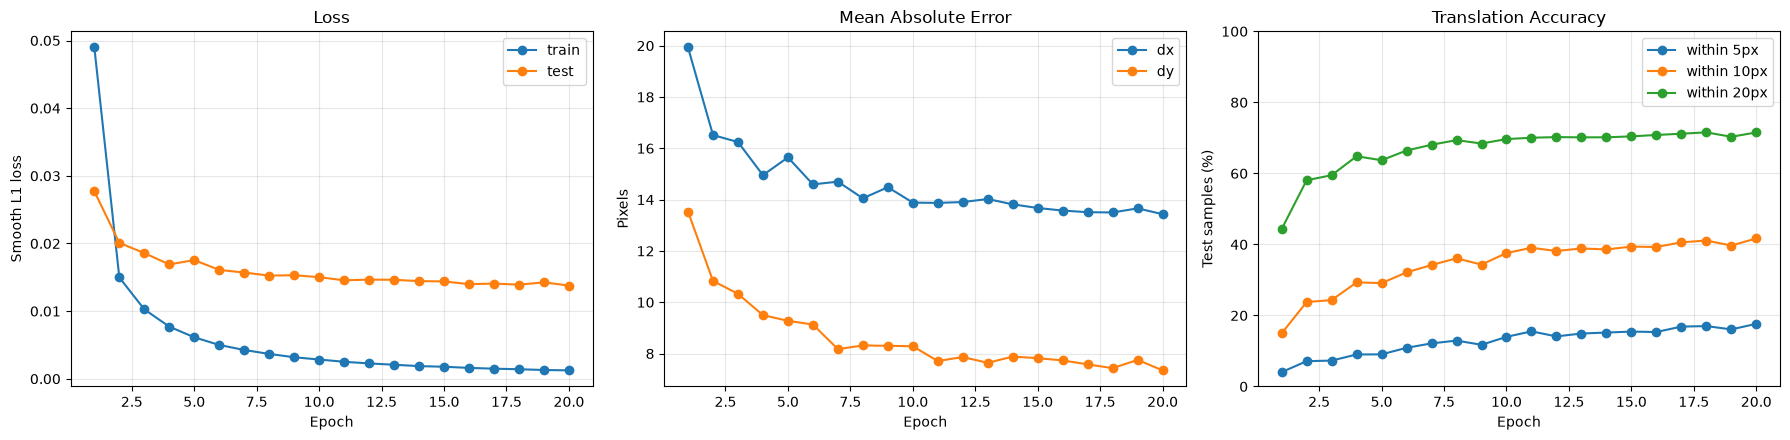

In [ ]:
def plot_training_history(history):
    if not history:
        print("No history to plot yet. Run the training cell first.")
        return

    epochs = [row["epoch"] for row in history]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o", label="train")
    axes[0].plot(epochs, [row["loss"] for row in history], marker="o", label="test")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Smooth L1 loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["mae_dx_px"] for row in history], marker="o", label="dx")
    axes[1].plot(epochs, [row["mae_dy_px"] for row in history], marker="o", label="dy")
    axes[1].set_title("Mean Absolute Error")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Pixels")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    accuracy_keys = [
        ("acc_within_5px", "within 5px"),
        ("acc_within_10px", "within 10px"),
        ("acc_within_20px", "within 20px"),
    ]
    for key, label in accuracy_keys:
        if key in history[0]:
            axes[2].plot(epochs, [row[key] * 100 for row in history], marker="o", label=label)
    axes[2].set_title("Translation Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Test samples (%)")
    axes[2].set_ylim(0, 100)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    fig.tight_layout()
    plt.show()


plot_training_history(history)

In [ ]:
@torch.no_grad()
def predict_batch(model, loader, max_items=8):
    model.eval()
    rgb, ir, target = next(iter(loader))
    rgb = rgb.to(DEVICE)
    ir = ir.to(DEVICE)
    output = model(rgb, ir)
    pred, _ = unpack_model_output(output)

    pred_px = denormalize_target(pred).cpu()
    target_px = denormalize_target(target).cpu()
    for i in range(min(max_items, rgb.size(0))):
        print(
            f"sample={i} "
            f"pred(dx,dy)={pred_px[i].tolist()} "
            f"target(dx,dy)={target_px[i].tolist()}"
        )


predict_batch(model, test_loader)


sample=0 pred(dx,dy)=[-44.50169372558594, -18.292892456054688] target(dx,dy)=[92.0, -42.0]
sample=1 pred(dx,dy)=[-99.70677185058594, 11.217378616333008] target(dx,dy)=[-79.0, -15.000000953674316]
sample=2 pred(dx,dy)=[-81.59748077392578, -17.282733917236328] target(dx,dy)=[41.0, -45.0]
sample=3 pred(dx,dy)=[-88.44015502929688, 27.66770362854004] target(dx,dy)=[43.0, -1.0]
sample=4 pred(dx,dy)=[-76.70446014404297, 55.454410552978516] target(dx,dy)=[89.0, 24.0]
sample=5 pred(dx,dy)=[-88.54716491699219, 54.814998626708984] target(dx,dy)=[-47.0, 43.0]
sample=6 pred(dx,dy)=[-94.45433044433594, 17.18390655517578] target(dx,dy)=[-73.0, -9.0]
sample=7 pred(dx,dy)=[-94.81185913085938, 55.39186477661133] target(dx,dy)=[-70.0, 52.999996185302734]
